## Step 9: Data Visualization (Matplotlib & Seaborn)

Visualizing the key findings from the SQL and Python analysis:
1. Monthly revenue trend (seasonality)
2. Profit by category (highlighting the Furniture margin issue)
3. Discount band vs average profit
4. Regional sales distribution
5. Profit margin distribution (outliers)
6. Top 10 products by sales

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/superstore_cleaned.csv')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['ShipDate'] = pd.to_datetime(df['ShipDate'])

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Data loaded:", df.shape)
df.head()

Data loaded: (9993, 26)


,RowID,OrderID,OrderDate,ShipDate,ShipMode,CustomerID,CustomerName,Segment,Country,City,...,ProductName,Sales,Quantity,Discount,Profit,OrderYear,OrderMonth,ShippingDelayDays,ProfitMargin,DiscountBand
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Houston,...,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,11,3,0.159986,No Discount
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Houston,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2016,11,3,0.299997,No Discount
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,San Diego,...,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2016,6,4,0.469904,No Discount
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Seattle,...,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2015,10,7,-0.399998,High (40%+)
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Seattle,...,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015,10,7,0.112651,Low (0-20%)


### 💻 Chart 1: Monthly Revenue Trend

Shows seasonality — revenue peaks in November and December each year.

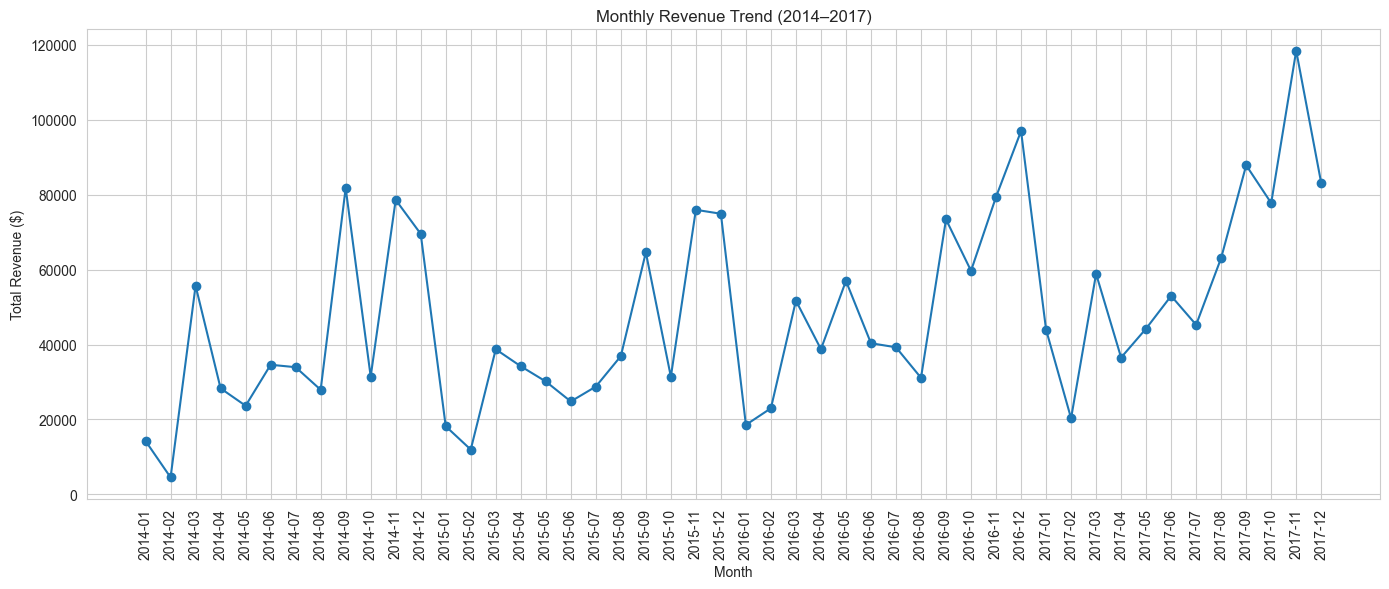

In [22]:
monthly_revenue = df.groupby(['OrderYear', 'OrderMonth'])['Sales'].sum().reset_index()
monthly_revenue['Period'] = monthly_revenue['OrderYear'].astype(str) + '-' + monthly_revenue['OrderMonth'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['Period'], monthly_revenue['Sales'], marker='o')
plt.title('Monthly Revenue Trend (2014–2017)')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../dashboard/chart1_monthly_revenue.png')
plt.show()

### 💻 Chart 2: Profit Margin by Category

Highlights that Furniture has the weakest margin despite solid sales volume.

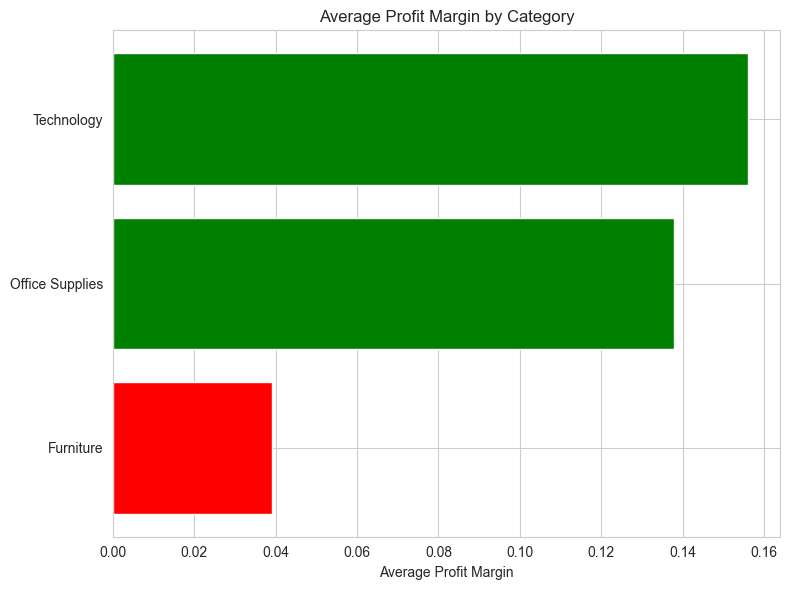

In [23]:
category_margin = df.groupby('Category')['ProfitMargin'].mean().sort_values()

colors = []
for value in category_margin.values:
    if value < 0.1:
        colors.append('red')
    else:
        colors.append('green')

plt.figure(figsize=(8, 6))
plt.barh(category_margin.index, category_margin.values, color=colors)
plt.title('Average Profit Margin by Category')
plt.xlabel('Average Profit Margin')
plt.tight_layout()
plt.savefig('../dashboard/chart2_category_margin.png')
plt.show()

### (Safety check) Recreate DiscountBand column

This column was created earlier in the first notebook. If it wasn't saved 
in the cleaned CSV, we recreate it here before using it in Chart 3.

In [24]:
def discount_band(d):
    if d == 0:
        return 'No Discount'
    elif d <= 0.2:
        return 'Low (0-20%)'
    elif d <= 0.4:
        return 'Medium (20-40%)'
    else:
        return 'High (40%+)'

if 'DiscountBand' not in df.columns:
    df['DiscountBand'] = df['Discount'].apply(discount_band)

print('DiscountBand' in df.columns)

True


### 💻 Chart 3: Discount Band vs Average Profit

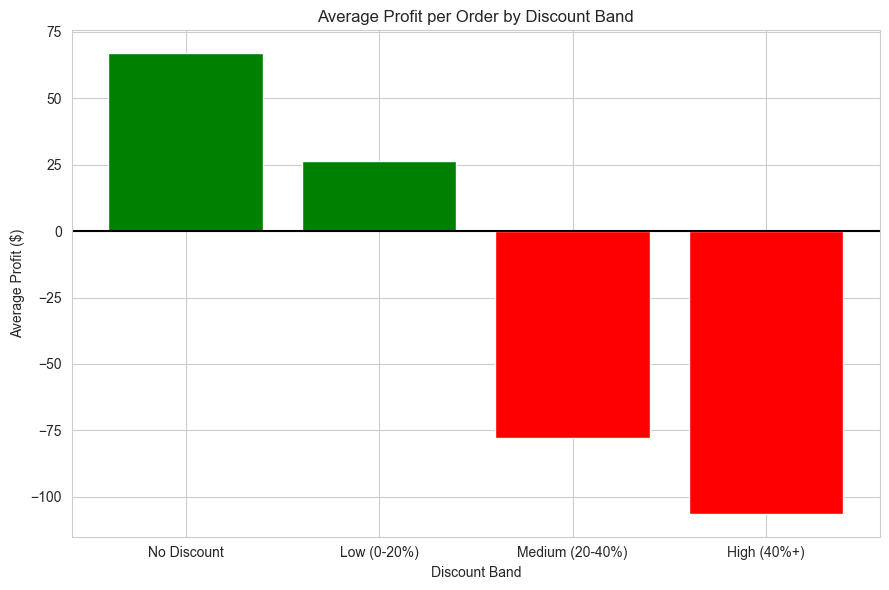

In [25]:
band_order = ['No Discount', 'Low (0-20%)', 'Medium (20-40%)', 'High (40%+)']
discount_profit = df.groupby('DiscountBand')['Profit'].mean().reindex(band_order)

colors = []
for value in discount_profit.values:
    if value > 0:
        colors.append('green')
    else:
        colors.append('red')

plt.figure(figsize=(9, 6))
plt.bar(discount_profit.index, discount_profit.values, color=colors)
plt.axhline(0, color='black')
plt.title('Average Profit per Order by Discount Band')
plt.xlabel('Discount Band')
plt.ylabel('Average Profit ($)')
plt.tight_layout()
plt.savefig('../dashboard/chart3_discount_vs_profit.png')
plt.show()

## 💻 Chart 4 — Regional Sales Distribution

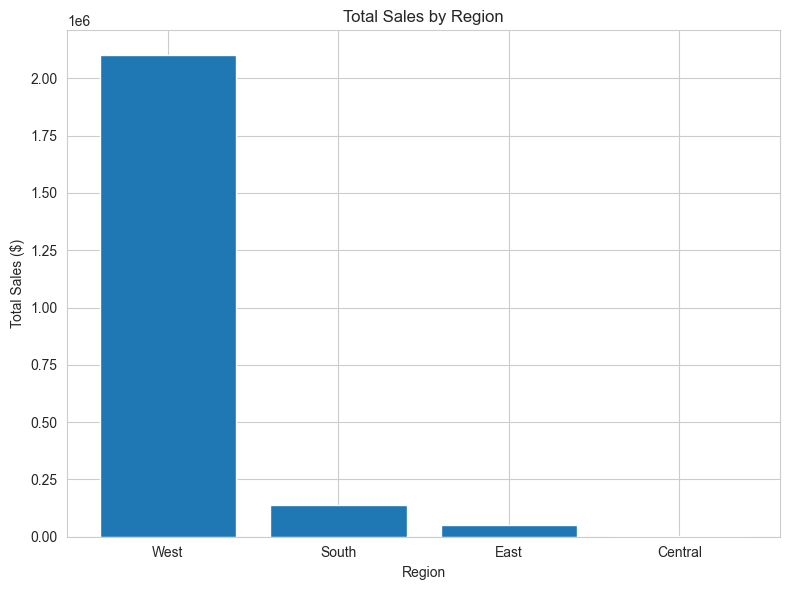

In [26]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
plt.bar(region_sales.index, region_sales.values)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../dashboard/chart4_regional_sales.png')
plt.show()

**Finding:** The West region accounts for the overwhelming majority of total 
sales (~$2.1M), dwarfing South (~$138K), East (~$52K), and Central (~$1.5K). 
This concentration suggests the business is heavily dependent on West region 
performance — a risk worth flagging for diversification.

## 💻 Chart 5 — Profit Margin Distribution

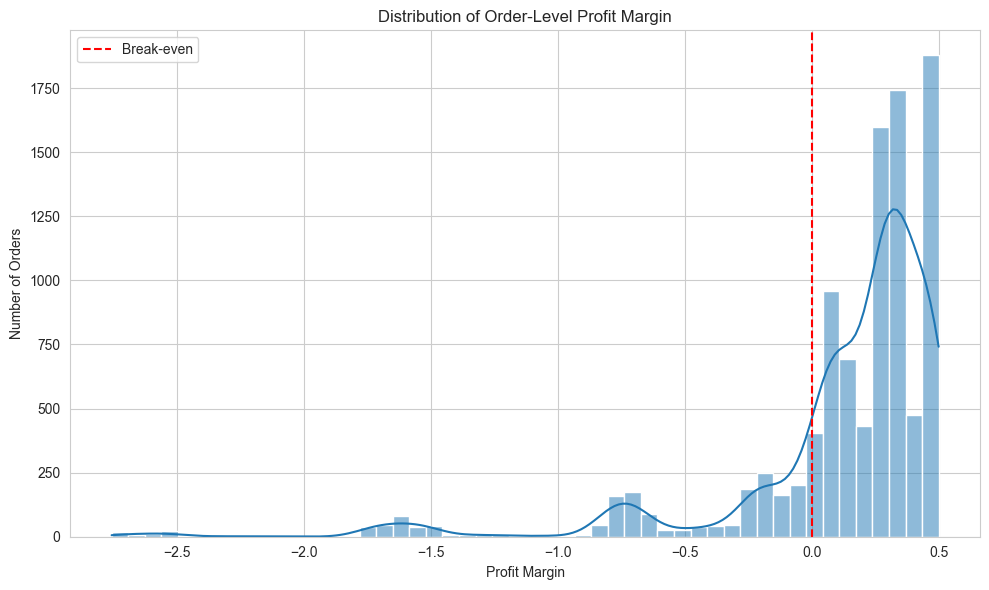

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(df['ProfitMargin'], bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--', label='Break-even')
plt.title('Distribution of Order-Level Profit Margin')
plt.xlabel('Profit Margin')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.savefig('../dashboard/chart5_margin_distribution.png')
plt.show()

**Finding:** The majority of orders fall between 0% and 50% profit margin, 
with a peak around 30-40% — indicating most of the business is healthy. 
However, there is a distinct left tail of loss-making orders, including a 
small cluster as low as -150% to -275% margin. These severe outliers likely 
correspond to the high-discount orders identified earlier and disproportionately 
pull down the overall average margin (12%) relative to the median (27%).

## 💻 Chart 6 — Top 10 Products by Sales

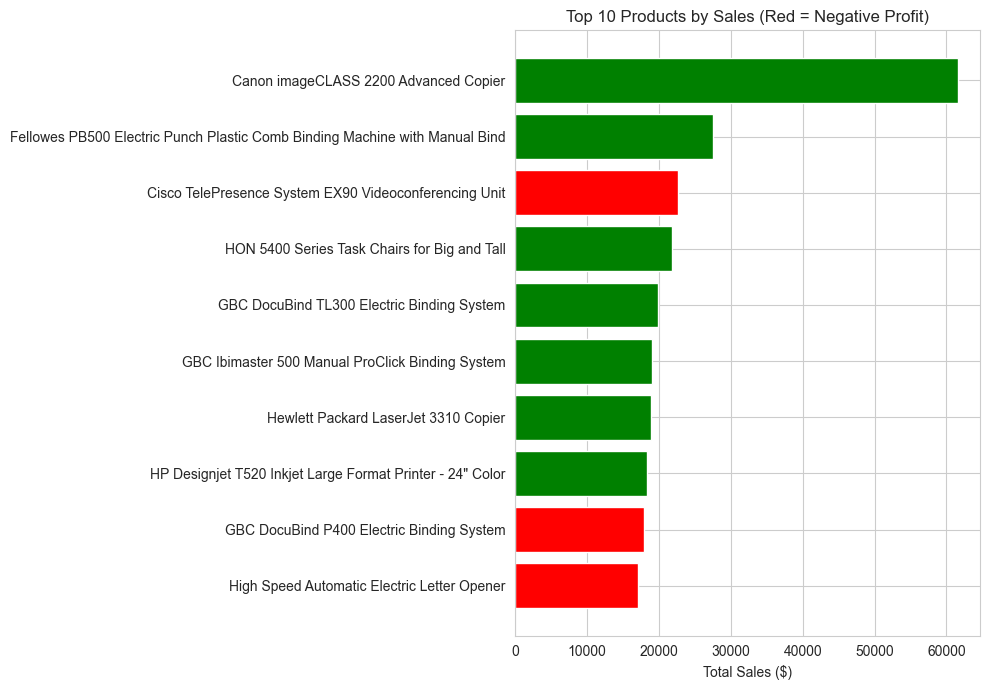

In [28]:
top_products = df.groupby('ProductName').agg(
    TotalSales=('Sales', 'sum'),
    TotalProfit=('Profit', 'sum')
).sort_values('TotalSales', ascending=False).head(10)

colors = []
for value in top_products['TotalProfit']:
    if value < 0:
        colors.append('red')
    else:
        colors.append('green')

plt.figure(figsize=(10, 7))
plt.barh(top_products.index[::-1], top_products['TotalSales'][::-1], color=colors[::-1])
plt.title('Top 10 Products by Sales (Red = Negative Profit)')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../dashboard/chart6_top_products.png')
plt.show()

**Finding:** 3 of the top 10 best-selling products by revenue — Cisco 
TelePresence System, GBC DocuBind P400, and the High Speed Automatic Electric 
Letter Opener — are actually unprofitable. High sales volume does not 
guarantee profitability, reinforcing the need to evaluate products by margin, 
not just revenue.

## Summary

This notebook validated the SQL analysis findings using Python, added two 
new insights (shipping delay has minimal profit impact; Furniture has a 
margin problem despite solid sales), and produced 6 visualizations covering 
seasonality, category margins, discount impact, regional distribution, 
margin spread, and product-level profitability.

**Next step:** Build an interactive Power BI dashboard using this same data, 
connected directly to the SQL Server database.